# Análisis Exploratorio de Datos (EDA)

Este cuaderno carga la misma fuente que `cargar_datos.ipynb` y documenta la calidad, estructura, distribuciones y relaciones de los datos antes de construir modelos.

## 1. Preparación y carga

Se importan las librerías, se fija una configuración de visualización y se localiza el archivo de Excel desde la raíz del proyecto. La ruta relativa permite ejecutar el cuaderno en otro equipo sin modificar código.

In [1]:
# Importamos las librerías necesarias para manipular y visualizar los datos.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Ajustamos la salida para inspeccionar tablas amplias sin truncarlas prematuramente.
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")

In [2]:
# Partimos de la ubicación de este cuaderno para construir una ruta portable al archivo fuente.
project_root = Path.cwd().resolve()
while project_root.name != "Henry-MLOps" and project_root.parent != project_root:
    project_root = project_root.parent

excel_path = project_root / "Base_de_datos.xlsx"
if not excel_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo de datos en: {excel_path}")

# Leemos la misma fuente utilizada en cargar_datos.ipynb y conservamos una copia sin transformaciones.
df = pd.read_excel(excel_path)
df_original = df.copy()

print(f"Archivo cargado: {excel_path.name}")
print(f"Dimensión inicial: {df.shape[0]:,} filas y {df.shape[1]:,} columnas")
display(df.head())

Archivo cargado: Base_de_datos.xlsx
Dimensión inicial: 10,763 filas y 23 columnas


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1


## 2. Estructura y calidad de los datos

Antes de analizar patrones, verificamos los tipos de datos, la cobertura de cada columna, los valores faltantes y los registros duplicados. Estos resultados orientan la limpieza y transformación posterior.

In [3]:
# Construimos un resumen por variable para revisar tipo, valores únicos y cobertura.
resumen_estructura = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "no_nulos": df.notna().sum(),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=True),
}).sort_values("porcentaje_nulos", ascending=False)

display(resumen_estructura)
print(f"Filas duplicadas: {df.duplicated().sum():,} ({df.duplicated().mean() * 100:.2f}%)")

,tipo_dato,no_nulos,nulos,porcentaje_nulos,valores_unicos
tendencia_ingresos,object,7831,2932,27.24,46
promedio_ingresos_datacredito,float64,7833,2930,27.22,5309
saldo_mora_codeudor,float64,10173,590,5.48,4
saldo_principal,float64,10358,405,3.76,8647
saldo_mora,float64,10607,156,1.45,55
saldo_total,float64,10607,156,1.45,8858
puntaje_datacredito,float64,10757,6,0.06,315
salario_cliente,int64,10763,0,0.00,1385
tipo_laboral,str,10763,0,0.00,2
edad_cliente,int64,10763,0,0.00,54


Filas duplicadas: 0 (0.00%)


In [ ]:
# Visualizamos únicamente las columnas que tienen ausencias para dimensionar el problema.
nulos_por_columna = resumen_estructura.query("nulos > 0")["porcentaje_nulos"].sort_values()

if nulos_por_columna.empty:
    print("No se encontraron valores faltantes.")
else:
    fig, ax = plt.subplots(figsize=(10, max(3, len(nulos_por_columna) * 0.45)))
    nulos_por_columna.plot.barh(ax=ax, color="#d95f02")
    ax.set(title="Porcentaje de valores faltantes", xlabel="Porcentaje", ylabel="Variable")
    plt.show()

## 3. Estadística descriptiva y distribuciones

Las variables numéricas se resumen con medidas de tendencia central y dispersión. Después se inspeccionan sus distribuciones para identificar asimetrías, escalas distintas o posibles errores de captura.

In [5]:
# Separamos variables por tipo para reutilizarlas en los análisis posteriores.
columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(f"Variables numéricas: {len(columnas_numericas)}")
print(f"Variables categóricas: {len(columnas_categoricas)}")
display(df[columnas_numericas].describe().T)

Variables numéricas: 20
Variables categóricas: 2


,count,mean,std,min,25%,50%,75%,max
tipo_credito,"10,763.00",5.41,2.34,4.00,4.00,4.00,9.00,68.00
capital_prestado,"10,763.00","2,434,315.00","1,909,642.76","360,000.00","1,224,831.00","1,921,920.00","3,084,840.00","41,444,152.80"
plazo_meses,"10,763.00",10.58,6.63,2.00,6.00,10.00,12.00,90.00
edad_cliente,"10,763.00",43.95,15.06,19.00,33.00,42.00,53.00,123.00
salario_cliente,"10,763.00","17,216,431.46","355,476,717.60",0.00,"2,000,000.00","3,000,000.00","4,875,808.00","22,000,000,000.00"
total_otros_prestamos,"10,763.00","6,238,869.65","118,418,316.94",0.00,"500,000.00","1,000,000.00","2,000,000.00","6,787,675,263.00"
cuota_pactada,"10,763.00","243,617.41","210,493.69","23,944.00","121,041.50","182,863.00","287,833.50","3,816,752.00"
puntaje,"10,763.00",91.17,16.47,-38.01,95.23,95.23,95.23,95.23
puntaje_datacredito,"10,757.00",780.79,104.88,-7.00,757.00,791.00,825.00,999.00
cant_creditosvigentes,"10,763.00",5.73,3.98,0.00,3.00,5.00,8.00,62.00


In [ ]:
# Graficamos histogramas de todas las columnas numéricas para detectar sesgos y concentraciones.
columnas_para_histograma = [columna for columna in columnas_numericas if columna != "Pago_atiempo"]
filas = int(np.ceil(len(columnas_para_histograma) / 3))
fig, axes = plt.subplots(filas, 3, figsize=(18, max(4, filas * 3.5)))

for axis, columna in zip(axes.flat, columnas_para_histograma):
    sns.histplot(data=df, x=columna, bins=30, kde=True, ax=axis, color="#1b9e77")
    axis.set_title(columna)

for axis in axes.flat[len(columnas_para_histograma):]:
    axis.set_visible(False)

fig.suptitle("Distribución de variables numéricas", y=1.01)
plt.tight_layout()
plt.show()

## 4. Variables categóricas y variable objetivo

Se revisa la frecuencia de categorías y el balance de `Pago_atiempo`. Un desbalance importante en la variable objetivo condiciona las métricas, la partición de datos y las técnicas de modelado.

In [7]:
# Mostramos la distribución de cada variable categórica y limitamos la tabla a las 15 categorías más frecuentes.
for columna in columnas_categoricas:
    print(f"\nFrecuencias de: {columna}")
    display(df[columna].value_counts(dropna=False).head(15).rename("frecuencia").to_frame())

# Confirmamos el balance de la variable objetivo de clasificación.
objetivo = "Pago_atiempo"
distribucion_objetivo = df[objetivo].value_counts(dropna=False).sort_index().rename("frecuencia").to_frame()
distribucion_objetivo["porcentaje"] = (distribucion_objetivo["frecuencia"] / len(df) * 100).round(2)
display(distribucion_objetivo)


Frecuencias de: tipo_laboral


,frecuencia
tipo_laboral,
Empleado,6754
Independiente,4009



Frecuencias de: tendencia_ingresos


,frecuencia
tendencia_ingresos,
Creciente,5294
NaN,2932
Decreciente,1291
Estable,1188
0,7
8315,6
1000000,4
9147,2
158042,1


,frecuencia,porcentaje
Pago_atiempo,,
0,511,4.75
1,10252,95.25


## 5. Relaciones entre variables

Se evalúan las correlaciones lineales entre variables numéricas y las diferencias de las variables frente a `Pago_atiempo`. Esto ayuda a detectar predictores potenciales, multicolinealidad y señales de fuga de información.

Variables numéricas más asociadas con Pago_atiempo:


,correlacion
puntaje,0.92
huella_consulta,-0.07
saldo_mora,-0.07
puntaje_datacredito,0.07
plazo_meses,-0.06
capital_prestado,-0.04
promedio_ingresos_datacredito,0.04
edad_cliente,0.03
creditos_sectorReal,-0.02
creditos_sectorFinanciero,0.02


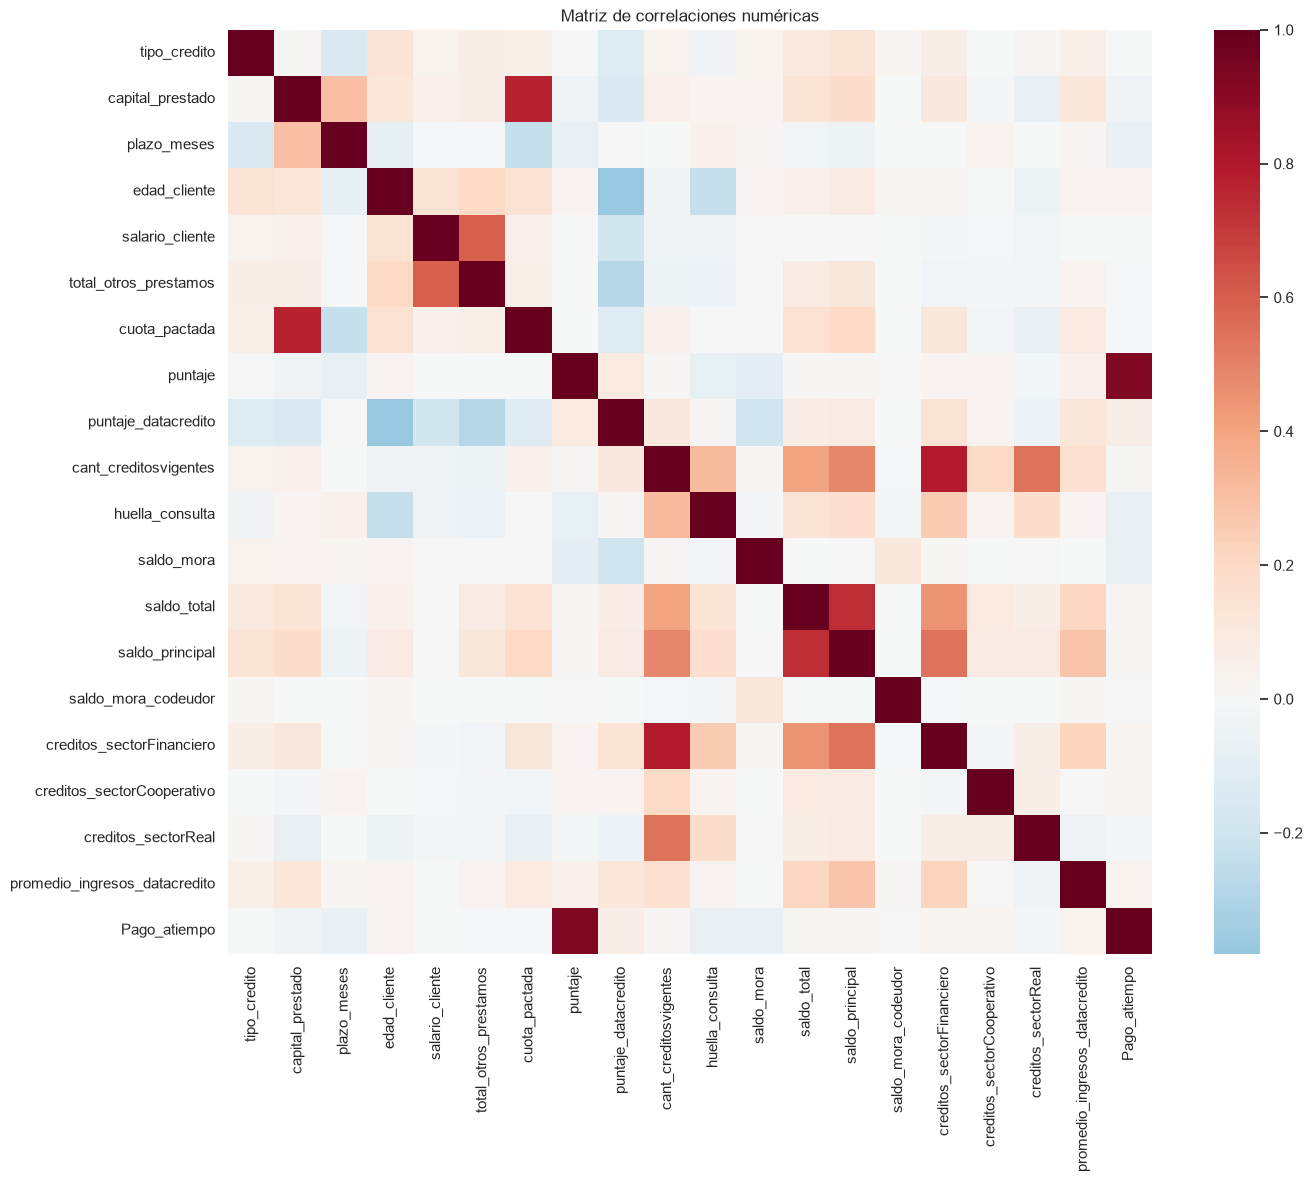

In [8]:
# Calculamos correlaciones de Pearson y priorizamos las asociaciones con la variable objetivo.
correlaciones = df[columnas_numericas].corr(numeric_only=True)
correlacion_objetivo = correlaciones[objetivo].drop(objetivo).sort_values(key=np.abs, ascending=False)

print("Variables numéricas más asociadas con Pago_atiempo:")
display(correlacion_objetivo.rename("correlacion").to_frame())

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(correlaciones, cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Matriz de correlaciones numéricas")
plt.show()

In [9]:
# Comparamos la mediana de cada predictor numérico entre quienes pagaron y quienes no pagaron a tiempo.
predictores_numericos = [columna for columna in columnas_numericas if columna != objetivo]
comparacion_objetivo = (
    df.groupby(objetivo)[predictores_numericos]
    .median()
    .T
    .rename(columns=lambda valor: f"mediana_pago_{valor}")
)
comparacion_objetivo["diferencia_medianas"] = comparacion_objetivo.iloc[:, -1] - comparacion_objetivo.iloc[:, 0]
display(comparacion_objetivo.sort_values("diferencia_medianas", key=np.abs, ascending=False))

Pago_atiempo,mediana_pago_0,mediana_pago_1,diferencia_medianas
capital_prestado,"2,268,000.00","1,908,446.40","-359,553.60"
promedio_ingresos_datacredito,"1,052,529.00","1,211,296.00","158,767.00"
total_otros_prestamos,"900,000.00","1,000,000.00","100,000.00"
cuota_pactada,"199,002.00","182,576.00","-16,426.00"
saldo_total,"14,518.50","16,308.00","1,789.50"
saldo_principal,"13,110.00","14,492.50","1,382.50"
puntaje,25.42,95.23,69.81
puntaje_datacredito,768.00,792.00,24.00
edad_cliente,38.00,42.00,4.00
huella_consulta,5.00,4.00,-1.00


## 6. Valores atípicos y evolución temporal

El método del rango intercuartílico (IQR) señala observaciones extremas de forma objetiva. No deben eliminarse automáticamente: en crédito pueden representar casos reales y relevantes. También se examina la evolución mensual de la tasa de pago.

In [10]:
# Cuantificamos observaciones fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] para cada predictor numérico.
reporte_atipicos = []
for columna in predictores_numericos:
    serie = df[columna].dropna()
    cuartil_1, cuartil_3 = serie.quantile([0.25, 0.75])
    rango_iqr = cuartil_3 - cuartil_1
    limite_inferior = cuartil_1 - 1.5 * rango_iqr
    limite_superior = cuartil_3 + 1.5 * rango_iqr
    cantidad_atipicos = ((serie < limite_inferior) | (serie > limite_superior)).sum()
    reporte_atipicos.append({
        "variable": columna,
        "atipicos": cantidad_atipicos,
        "porcentaje_atipicos": round(cantidad_atipicos / len(serie) * 100, 2),
    })

reporte_atipicos = pd.DataFrame(reporte_atipicos).sort_values("porcentaje_atipicos", ascending=False)
display(reporte_atipicos)

,variable,atipicos,porcentaje_atipicos
16,creditos_sectorCooperativo,1895,17.61
7,puntaje,1356,12.60
18,promedio_ingresos_datacredito,784,10.01
13,saldo_principal,951,9.18
12,saldo_total,970,9.14
2,plazo_meses,869,8.07
6,cuota_pactada,765,7.11
4,salario_cliente,718,6.67
5,total_otros_prestamos,589,5.47
1,capital_prestado,550,5.11


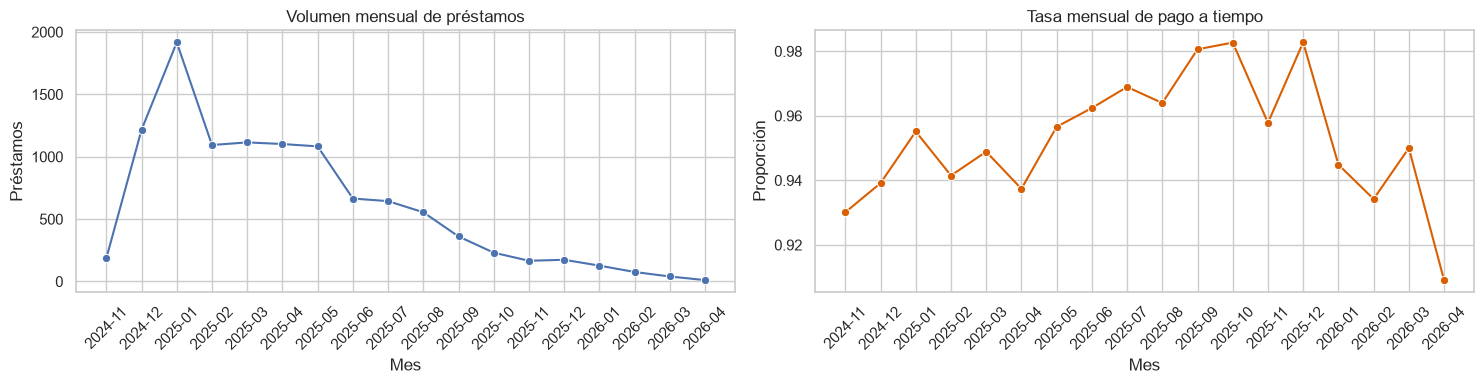

In [12]:
# Agregamos por mes para observar cambios en el volumen de préstamos y en la tasa de pago a tiempo.
serie_mensual = (
    df.assign(mes=df["fecha_prestamo"].dt.to_period("M").astype(str))
    .groupby("mes")
    .agg(prestamos=(objetivo, "size"), tasa_pago_a_tiempo=(objetivo, "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.lineplot(data=serie_mensual, x="mes", y="prestamos", marker="o", ax=axes[0])
sns.lineplot(data=serie_mensual, x="mes", y="tasa_pago_a_tiempo", marker="o", ax=axes[1], color="#d95f02")
axes[0].set(title="Volumen mensual de préstamos", xlabel="Mes", ylabel="Préstamos")
axes[1].set(title="Tasa mensual de pago a tiempo", xlabel="Mes", ylabel="Proporción")
for axis in axes:
    axis.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Conclusiones y siguientes pasos

El reporte siguiente concentra los indicadores de calidad. Antes de entrenar un modelo, se recomienda: definir el tratamiento de nulos, investigar los valores atípicos, validar si `puntaje` está disponible al momento de originar el crédito y usar partición estratificada junto con métricas apropiadas para la clase minoritaria.

In [11]:
# Consolidamos los indicadores clave para reutilizarlos en la fase de preparación de datos.
reporte_eda = pd.DataFrame({
    "indicador": [
        "Registros", "Variables", "Duplicados", "Nulos totales",
        "Tasa de pago a tiempo", "Clase minoritaria", "Mayor correlación absoluta con el objetivo"
    ],
    "valor": [
        len(df), len(df.columns), int(df.duplicated().sum()), int(df.isna().sum().sum()),
        f"{df[objetivo].mean() * 100:.2f}%", f"{(1 - df[objetivo].mean()) * 100:.2f}%",
        f"{correlacion_objetivo.index[0]} ({correlacion_objetivo.iloc[0]:.2f})"
    ],
})
display(reporte_eda)

,indicador,valor
0,Registros,10763
1,Variables,23
2,Duplicados,0
3,Nulos totales,7175
4,Tasa de pago a tiempo,95.25%
5,Clase minoritaria,4.75%
6,Mayor correlación absoluta con el objetivo,puntaje (0.92)
